In [1]:
library(Seurat)
library(tidyverse)

The legacy packages maptools, rgdal, and rgeos, underpinning the sp package,
which was just loaded, will retire in October 2023.
Please refer to R-spatial evolution reports for details, especially
https://r-spatial.org/r/2023/05/15/evolution4.html.
It may be desirable to make the sf package available;
package maintainers should consider adding sf to Suggests:.
The sp package is now running under evolution status 2
     (status 2 uses the sf package in place of rgdal)

Attaching SeuratObject

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.3     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all confli

# Before you get started

Create a similar directory structure:

    /metaplasia_analysis
    ..../data
    ......../rawFiles
    ......../rdsFiles
    ..../plots
    ..../csv_files
    ..../nb1_preprocessing_data_from_source.ipynb
    ..../nb2_adding_module_scores.ipynb
    ..../nb3_find_markers.ipynb
    ..../nb4_visualizations.ipynb


Then download the data from the links below to the rawFiles directory, and run the following code. 

Please note that you may need to rename the files after downloading them into rawFiles directory.

# Tosti, L. et al., Gastroenterology 2021

[Single-Nucleus and In Situ RNA–Sequencing Reveal Cell Topographies in the Human Pancreas](https://doi.org/10.1053/j.gastro.2020.11.010)

[Data download](http://singlecell.charite.de/pancreas)

## Human adult pancreas

In [7]:
obj.adult_pancreas <- readRDS("./data/rawFiles/tosti_adult_pancreas.rds")

obj.adult_pancreas
dim(obj.adult_pancreas@meta.data)
head(obj.adult_pancreas@meta.data)

An object of class Seurat 
45815 features across 112563 samples within 2 assays 
Active assay: RNA (43815 features, 0 variable features)
 1 other assay present: integrated
 2 dimensional reductions calculated: pca, umap

[1] 112563      9

,nCount_RNA,nFeature_RNA,sample_ID,patient_ID,sex,age,pancreas_location,procurement_lab,Cluster
,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>
AAACCTGAGAAGGTGA_6,896,655,AFES448_FF1,AFES448,male,30,head,Stanford,Acinar-s
AAACCTGAGATGTAAC_6,601,461,AFES448_FF1,AFES448,male,30,head,Stanford,Acinar-s
AAACCTGAGCACCGTC_6,811,641,AFES448_FF1,AFES448,male,30,head,Stanford,Acinar-i
AAACCTGAGCGCTTAT_6,685,509,AFES448_FF1,AFES448,male,30,head,Stanford,Acinar-i
AAACCTGAGCTAGCCC_6,907,671,AFES448_FF1,AFES448,male,30,head,Stanford,Acinar-i
AAACCTGAGTTACGGG_6,611,510,AFES448_FF1,AFES448,male,30,head,Stanford,Acinar-i


In [8]:
# Pool all acinar cell populations
obj.adult_pancreas@meta.data <- obj.adult_pancreas@meta.data |>
    mutate(hla.acinar = case_when(str_detect(string = Cluster, pattern = "Acinar") ~ "Acinar", 
                                  .default = Cluster))

table(obj.adult_pancreas@meta.data$Cluster, useNA = "always")
table(obj.adult_pancreas@meta.data$hla.acinar, useNA = "always")


        Macrophage        Acinar-REG+      MUC5B+ Ductal           Acinar-i 
               833               3689                225              43923 
          Acinar-s             Ductal              Alpha               Beta 
             31716              20610               1607               4246 
             Gamma              Delta Quiescent Stellate Activated Stellate 
                90               1022                178               2225 
       Endothelial            Schwann               <NA> 
              2119                 80                  0 


            Acinar Activated Stellate              Alpha               Beta 
             79328               2225               1607               4246 
             Delta             Ductal        Endothelial              Gamma 
              1022              20610               2119                 90 
        Macrophage      MUC5B+ Ductal Quiescent Stellate            Schwann 
               833                225                178                 80 
              <NA> 
                 0 

In [9]:
Epi.adult_pancreas <- c("Alpha", "Beta", "Delta", "Gamma", "Acinar", "MUC5B+ Ductal", "Ductal")
celltypes.adult_pancreas <- unique(obj.adult_pancreas@meta.data$hla.acinar)
nonEpi.adult_pancreas <- setdiff(celltypes.adult_pancreas, Epi.adult_pancreas)

obj.adult_pancreas@meta.data <- obj.adult_pancreas@meta.data |>
    mutate(ann.epi = case_when(hla.acinar %in% Epi.adult_pancreas ~ "Epithelial", 
                               .default = "Non-Epithelial"))

table(obj.adult_pancreas@meta.data$ann.epi, useNA = "always")


    Epithelial Non-Epithelial           <NA> 
        107128           5435              0 

### get epi.adult_pancreas

In [11]:
epi.adult_pancreas <- subset(x = obj.adult_pancreas, 
                             subset = hla.acinar %in% Epi.adult_pancreas)
epi.adult_pancreas

Idents(epi.adult_pancreas) <- "Cluster"
levels(Idents(epi.adult_pancreas))

An object of class Seurat 
45815 features across 107128 samples within 2 assays 
Active assay: RNA (43815 features, 0 variable features)
 1 other assay present: integrated
 2 dimensional reductions calculated: pca, umap

[1] "Acinar-REG+"   "MUC5B+ Ductal" "Acinar-i"      "Acinar-s"     
[5] "Ductal"        "Alpha"         "Beta"          "Gamma"        
[9] "Delta"

In [12]:
geneUniv.epi.adult_pancreas <- rownames(epi.adult_pancreas@assays$RNA@counts)
length(geneUniv.epi.adult_pancreas)
head(geneUniv.epi.adult_pancreas)

[1] 43815

[1] "A1BG-AS1" "A1BG"     "A1CF"     "A2M-AS1"  "A2ML1"    "A2MP1"

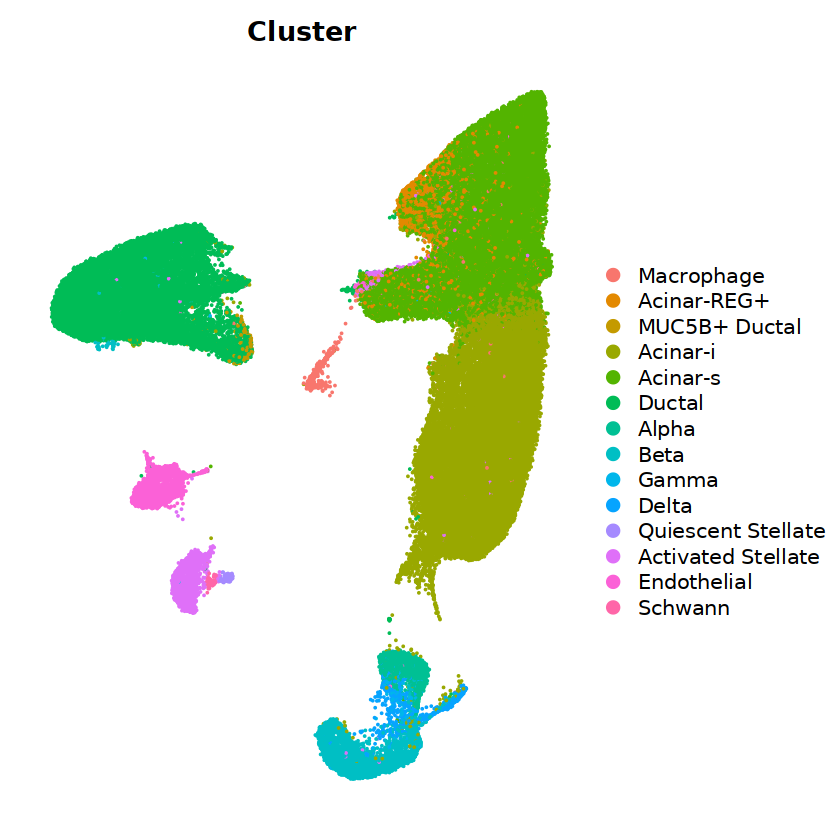

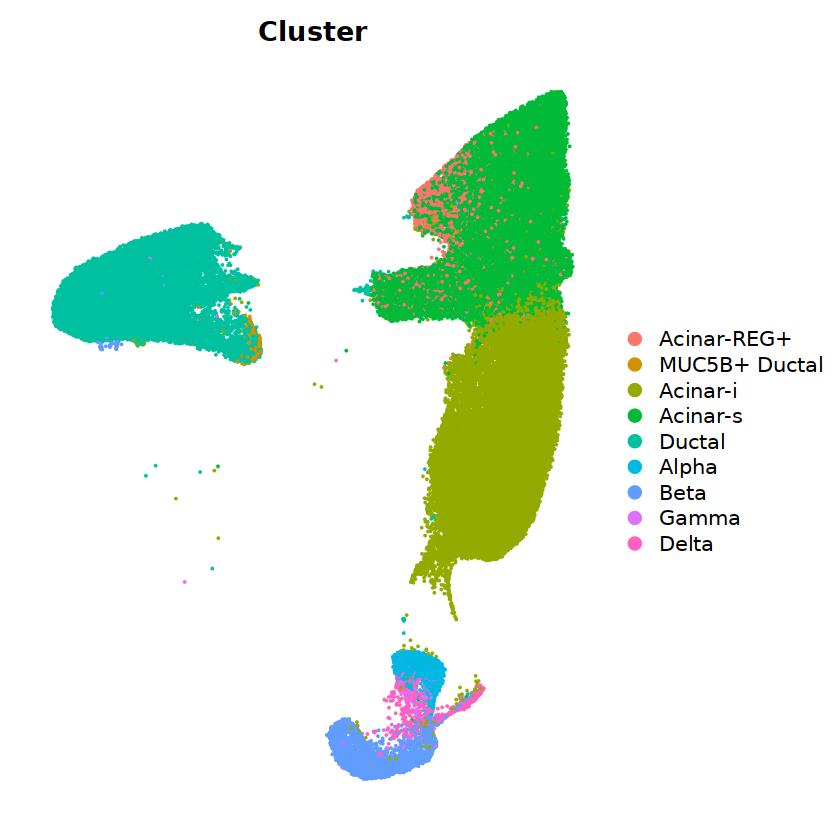

In [14]:
# Tosti et al., Figure 2A
DimPlot(object = obj.adult_pancreas, reduction = "umap", group.by = "Cluster", raster = FALSE) + NoAxes()
DimPlot(object = epi.adult_pancreas, reduction = "umap", group.by = "Cluster", raster = FALSE) + NoAxes()

In [23]:
saveRDS(epi.adult_pancreas, "./data/rdsFiles/tosti_pancreas.epi.adult_pancreas.rds")
saveRDS(obj.adult_pancreas, "./data/rdsFiles/tosti_pancreas.all.adult_pancreas.rds")

## Human chronic pancreatitis

In [16]:
obj.chronic_pancreatitis <- readRDS("./data/rawFiles/tosti_chronic_pancreatitis.rds")

obj.chronic_pancreatitis
dim(obj.chronic_pancreatitis@meta.data)
head(obj.chronic_pancreatitis@meta.data)

An object of class Seurat 
26782 features across 2666 samples within 2 assays 
Active assay: RNA (24782 features, 0 variable features)
 1 other assay present: integrated
 1 dimensional reduction calculated: umap

[1] 2666    9

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,sample_ID,Cluster,patient_ID,sex,age
,<chr>,<dbl>,<int>,<dbl>,<chr>,<fct>,<chr>,<chr>,<chr>
AAACGAAAGCATCCTA_1,pancreatitis,7052,3304,0.5530346,TUM_CP1,Endothelial,TUM_CP1,male,71
AAACGAACACTCATAG_1,pancreatitis,8928,4183,0.6720430,TUM_CP1,Ductal,TUM_CP1,male,71
AAACGAAGTATTCTCT_1,pancreatitis,11008,4826,2.4345930,TUM_CP1,MUC5B+ Ductal,TUM_CP1,male,71
AAACGAAGTTCTTAGG_1,pancreatitis,13008,4386,0.5381304,TUM_CP1,Beta,TUM_CP1,male,71
AAACGAAGTTGCGTAT_1,pancreatitis,4423,2372,0.6104454,TUM_CP1,Tuft,TUM_CP1,male,71
AAACGAATCAAGAATG_1,pancreatitis,9526,4010,1.0392610,TUM_CP1,Beta,TUM_CP1,male,71


In [17]:
obj.chronic_pancreatitis@meta.data <- obj.chronic_pancreatitis@meta.data |>
    mutate(hla.acinar = case_when(str_detect(string = Cluster, pattern = "Acinar") ~ "Acinar", 
                                  .default = Cluster))

table(obj.chronic_pancreatitis@meta.data$Cluster, useNA = "always")
table(obj.chronic_pancreatitis@meta.data$hla.acinar, useNA = "always")


       Acinar-REG+             Ductal      MUC5B+ Ductal              Alpha 
                53                220                667                 73 
              Beta Quiescent Stellate Activated Stellate        Endothelial 
                49                 22                437                103 
        Macrophage            Schwann                  B                  T 
               316                  9                106                415 
              Mast           Monocyte               Tuft               <NA> 
                21                 76                 99                  0 


            Acinar Activated Stellate              Alpha                  B 
                53                437                 73                106 
              Beta             Ductal        Endothelial         Macrophage 
                49                220                103                316 
              Mast           Monocyte      MUC5B+ Ductal Quiescent Stellate 
                21                 76                667                 22 
           Schwann                  T               Tuft               <NA> 
                 9                415                 99                  0 

In [18]:
Epi.chronic_pancreatitis <- c("Alpha", "Beta", "Tuft", "Acinar", "MUC5B+ Ductal", "Ductal")
celltypes.chronic_pancreatitis <- unique(obj.chronic_pancreatitis@meta.data$hla.acinar)
nonEpi.chronic_pancreatitis <- setdiff(celltypes.chronic_pancreatitis, Epi.chronic_pancreatitis)

obj.chronic_pancreatitis@meta.data <- obj.chronic_pancreatitis@meta.data |>
    mutate(ann.epi = case_when(hla.acinar %in% Epi.chronic_pancreatitis ~ "Epithelial", 
                               .default = "Non-Epithelial"))

table(obj.chronic_pancreatitis@meta.data$ann.epi, useNA = "always")


    Epithelial Non-Epithelial           <NA> 
          1161           1505              0 

### get epi.chronic_pancreatitis

In [19]:
epi.chronic_pancreatitis <- subset(x = obj.chronic_pancreatitis, 
                                   subset = hla.acinar %in% Epi.chronic_pancreatitis)
epi.chronic_pancreatitis

Idents(epi.chronic_pancreatitis) <- "Cluster"
levels(Idents(epi.chronic_pancreatitis))

An object of class Seurat 
26782 features across 1161 samples within 2 assays 
Active assay: RNA (24782 features, 0 variable features)
 1 other assay present: integrated
 1 dimensional reduction calculated: umap

[1] "Acinar-REG+"   "Ductal"        "MUC5B+ Ductal" "Alpha"        
[5] "Beta"          "Tuft"

In [20]:
geneUniv.epi.chronic_pancreatitis <- rownames(epi.chronic_pancreatitis@assays$RNA@counts)
length(geneUniv.epi.chronic_pancreatitis)
head(geneUniv.epi.chronic_pancreatitis)

[1] 24782

[1] "RP11-34P13.7"  "AL627309.1"    "AP006222.2"    "RP4-669L17.10"
[5] "RP5-857K21.2"  "RP5-857K21.4"

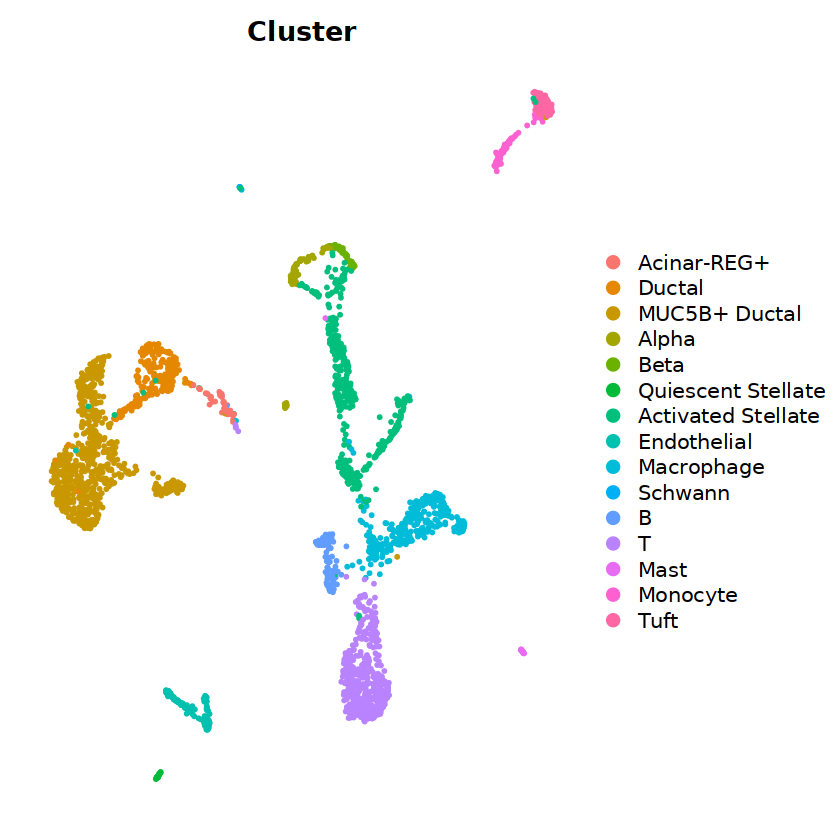

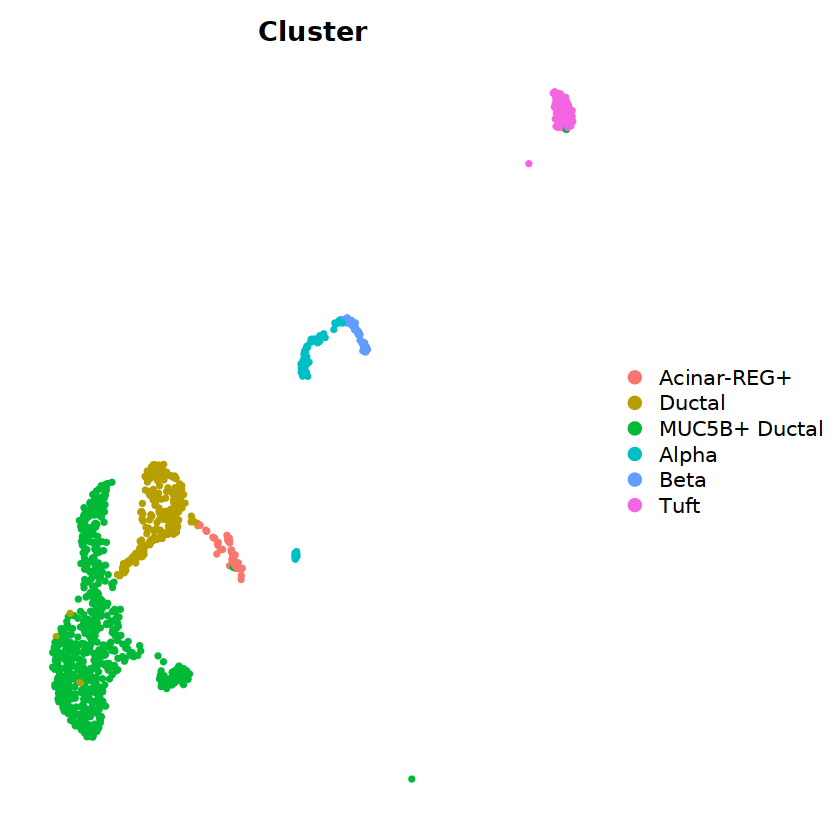

In [21]:
# Tosti et al., Supplementary fig 10C
DimPlot(object = obj.chronic_pancreatitis, reduction = "umap", group.by = "Cluster") + NoAxes()
DimPlot(object = epi.chronic_pancreatitis, reduction = "umap", group.by = "Cluster") + NoAxes()

In [24]:
saveRDS(epi.chronic_pancreatitis, "./data/rdsFiles/tosti_pancreas.epi.chronic_pancreatitis.rds")
saveRDS(obj.chronic_pancreatitis, "./data/rdsFiles/tosti_pancreas.all.chronic_pancreatitis.rds")

# Ma, Z. et al., Gastroenterology 2022

[Data download: GSE172380](https://www.ncbi.xyz/geo/query/acc.cgi?acc=GSE172380)

[Single-Cell Transcriptomics Reveals a Conserved Metaplasia Program in Pancreatic Injury](https://doi.org/10.1053/j.gastro.2021.10.027)

In [47]:
counts.yfpPositive <- read_csv("./data/rawFiles/GSE172380_Feature_Barcode_rawCountMatrix_Filtered-YFP+_all-samples_QCed.csv") |>
    column_to_rownames("...1")
meta.yfpPositive <- read_csv("./data/rawFiles/GSE172380_Cluster+CelltypeLabel_YFP+_all-samples_QCed.csv") |>
    column_to_rownames("...1")

New names:
• `` -> `...1`
Rows: 32288 Columns: 13363
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr     (1): ...1
dbl (13362): AAACCCACACTCACTC.2wks.A8324, AAACCCACAGGCATTT.2wks.A8324, AAACC...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `` -> `...1`
Rows: 13362 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): ...1, celltypeLabel
dbl (1): clusters

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [48]:
meta.yfpPositive$cellBarcode <- rownames(meta.yfpPositive)
rownames(meta.yfpPositive) <- gsub(pattern = "-", replacement = ".", x = meta.yfpPositive$cellBarcode)

In [49]:
obj.yfpPositive <- CreateSeuratObject(counts = counts.yfpPositive, meta.data = meta.yfpPositive)

obj.yfpPositive
dim(obj.yfpPositive@meta.data)
head(obj.yfpPositive@meta.data)

An object of class Seurat 
32288 features across 13362 samples within 1 assay 
Active assay: RNA (32288 features, 0 variable features)

[1] 13362     6

,orig.ident,nCount_RNA,nFeature_RNA,clusters,celltypeLabel,cellBarcode
,<fct>,<dbl>,<int>,<dbl>,<chr>,<chr>
AAACCCACACTCACTC.2wks.A8324,SeuratProject,16196,4794,11,EEC,AAACCCACACTCACTC-2wks-A8324
AAACCCACAGGCATTT.2wks.A8324,SeuratProject,47452,6743,2,MucinDuctal,AAACCCACAGGCATTT-2wks-A8324
AAACCCAGTGAGTTTC.2wks.A8324,SeuratProject,22929,5617,10,Tuft,AAACCCAGTGAGTTTC-2wks-A8324
AAACCCATCCTTATAC.2wks.A8324,SeuratProject,9305,1419,0,Acinar,AAACCCATCCTTATAC-2wks-A8324
AAACCCATCGCTCCTA.2wks.A8324,SeuratProject,29731,5101,2,MucinDuctal,AAACCCATCGCTCCTA-2wks-A8324
AAACGAACAGGAAGTC.2wks.A8324,SeuratProject,66120,7282,2,MucinDuctal,AAACGAACAGGAAGTC-2wks-A8324


In [50]:
message("NormalizeData...")
obj.yfpPositive <- NormalizeData(object = obj.yfpPositive, 
                         normalization.method = "LogNormalize", 
                         scale.factor = 10000)
message("FindVariableFeatures...")
obj.yfpPositive <- FindVariableFeatures(object = obj.yfpPositive, 
                                selection.method = "vst", 
                                nfeatures = 2000)
message("ScaleData...")
obj.yfpPositive <- ScaleData(object = obj.yfpPositive, 
                     # vars.to.regress = c("nFeature_RNA", "S.Score", "G2M.Score"), 
                     features = VariableFeatures(object = obj.yfpPositive))
message("RunPCA...")
obj.yfpPositive <- RunPCA(object = obj.yfpPositive, features = VariableFeatures(object = obj.yfpPositive))

sigPCs <- 20
groupbyVariable <- "sample_ID"

# message("RunHarmony...")
# # defaults for for RunHarmony: reduction = "pca", plot_convergence = FALSE,
# obj.yfpPositive <- harmony::RunHarmony(object = obj.yfpPositive, 
#                                group.by.vars = groupbyVariable) 
message("RunUMAP...")
obj.yfpPositive <- RunUMAP(object = obj.yfpPositive, 
                           seed.use = 1,
                           reduction = "pca", # harmony or pca
                           dims = 1:sigPCs)
obj.yfpPositive

NormalizeData...

FindVariableFeatures...

ScaleData...

Centering and scaling data matrix

RunPCA...

PC_ 1 
Positive:  Crip1, Gnai2, Plac8, Avil, Fyb, Dclk1, Alox5ap, Bcl2l14, Hck, Aldh2 
	   Bpgm, Espn, Rgs13, Spib, Krt8, Trpm5, Adh1, Ltc4s, Alox5, Sh2d6 
	   Anxa4, Pik3r5, Skap2, Lima1, Ptpn6, Calml4, Bmx, Sh2d7, Ly6g6f, Krt18 
Negative:  Cela1, Pla2g1b, Cpa1, Cel, Cela3b, Ctrl, Cpb1, Sycn, Prss2, Pdia2 
	   Klk1, Cpa2, Rnase1, Cela2a, Zg16, Cuzd1, Try5, Pnliprp2, 2210010C04Rik, Ctrc 
	   Try10, Fkbp11, Pnlip, Erp27, Serpini2, Spink1, Arhgdig, Tmem97, Aqp12, Gm2663 
PC_ 2 
Positive:  Tmem45a, Cldn2, Spp1, Ttr, Ctse, Car2, Krt19, Pigr, Cfi, Golm1 
	   Wfdc18, Gkn3, Onecut2, Zfp36l2, Cxcl17, Degs1, Cd2ap, Atp1b1, Golim4, Gas6 
	   Slc12a2, Kcne3, Gpx2, Pglyrp1, S100a6, Smpd3, Vsig1, Foxq1, Ces2g, Cxadr 
Negative:  Spink1, Cel, Cpa2, Cela2a, Cpb1, Ctrl, Cela3b, Cpa1, Rnase1, Prss2 
	   Zg16, Cuzd1, Ctrc, Try10, Serpini2, Try5, 2210010C04Rik, Erp27, Pnlip, Sycn 
	   Gamt, Pnliprp2, Psm

An object of class Seurat 
32288 features across 13362 samples within 1 assay 
Active assay: RNA (32288 features, 2000 variable features)
 2 dimensional reductions calculated: pca, umap

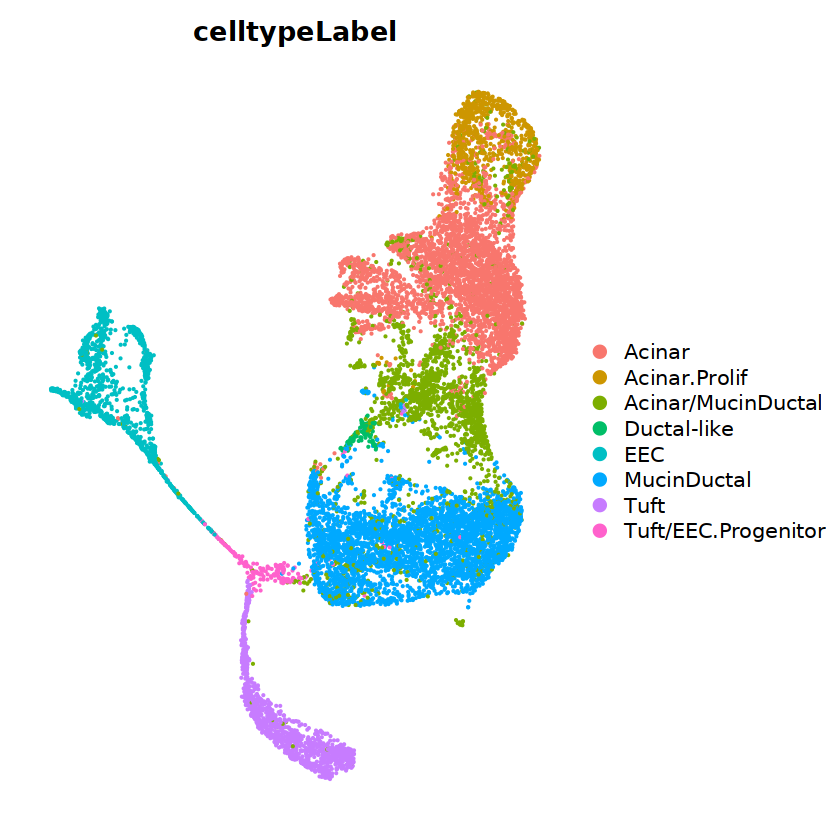

In [52]:
DimPlot(object = obj.yfpPositive, reduction = "umap", group.by = "celltypeLabel") + NoAxes()

In [53]:
table(obj.yfpPositive@meta.data$celltypeLabel, useNA = "always")


             Acinar       Acinar.Prolif  Acinar/MucinDuctal         Ductal-like 
               3698                 894                1955                 139 
                EEC         MucinDuctal                Tuft Tuft/EEC.Progenitor 
               1208                3983                1280                 205 
               <NA> 
                  0 

In [54]:
saveRDS(obj.yfpPositive, "./data/rdsFiles/ma_pancreas_injury.yfpPositive.rds")

# Burdziak, C. et al., Science 2023

[Data download: GSE207938](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE207938)

In [64]:
library(sceasy)

In [65]:
reticulate::py_config()

python:         /sc/arion/work/kumara82/conda/envs/scrna/bin/python3
libpython:      /sc/arion/work/kumara82/conda/envs/scrna/lib/libpython3.10.so
pythonhome:     /sc/arion/work/kumara82/conda/envs/scrna:/sc/arion/work/kumara82/conda/envs/scrna
version:        3.10.12 | packaged by conda-forge | (main, Jun 23 2023, 22:40:32) [GCC 12.3.0]
numpy:          /sc/arion/work/kumara82/conda/envs/scrna/lib/python3.10/site-packages/numpy
numpy_version:  1.25.2
anndata:        /sc/arion/work/kumara82/conda/envs/scrna/lib/python3.10/site-packages/anndata

python versions found: 
 /sc/arion/work/kumara82/conda/envs/scrna/bin/python3
 /sc/arion/work/kumara82/conda/envs/scrna/bin/python

In [66]:
ad_path <- "./data/rawFiles/GSE207938_ProgressionCohort.h5ad"
sceasy::convertFormat(ad_path, from = "anndata", to = "seurat", outFile = "GSE207938_ProgressionCohort.rds")

X -> counts



An object of class Seurat 
16826 features across 28131 samples within 1 assay 
Active assay: RNA (16826 features, 0 variable features)
 2 dimensional reductions calculated: EMBED, PCA

In [67]:
file.rename(from = "GSE207938_ProgressionCohort.rds", to = "./data/rawFiles/GSE207938_ProgressionCohort.rds")
file.exists("./data/rawFiles/GSE207938_ProgressionCohort.rds")

[1] TRUE

[1] TRUE

In [68]:
obj.burdziak_pdac_models <- readRDS("./data/rawFiles/GSE207938_ProgressionCohort.rds")
obj.burdziak_pdac_models

An object of class Seurat 
16826 features across 28131 samples within 1 assay 
Active assay: RNA (16826 features, 0 variable features)
 2 dimensional reductions calculated: EMBED, PCA

In [69]:
# Log2 transform sparse counts with a pseudocount, keeping it sparse
lognorm_counts <- log2(obj.burdziak_pdac_models[["RNA"]]@counts + 0.1)  # Add pseudocount to all entries and apply log2 transformation
# Convert to CsparseMatrix format if needed
lognorm_counts <- as(lognorm_counts, "CsparseMatrix")
# Assign to data slot
obj.burdziak_pdac_models[["RNA"]]@data <- lognorm_counts

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 3.5 GiB”


In [72]:
saveRDS(obj.burdziak_pdac_models, "./data/rdsFiles/burdziak_pdac_models.progressionCohort.rds")

# Chen, B. et al., Cell 2021

[Differential pre-malignant programs and microenvironment chart distinct paths to malignancy in human colorectal polyps](https://doi.org/10.1016/j.cell.2021.11.031)

[Data download link](https://explore.data.humancellatlas.org/projects/50154d1e-2308-44bf-9608-10c7afaa560b)

[HTAN Precancer atlas link](https://humantumoratlas.org/hta11)

In [2]:
epi.dis <- readRDS("./data/rawFiles/VUMC_HTAN_DIS_EPI_CELLxGENE_23March2023.rds")
epi.val <- readRDS("./data/rawFiles/VUMC_HTAN_VAL_EPI_CELLxGENE_23March2023.rds")

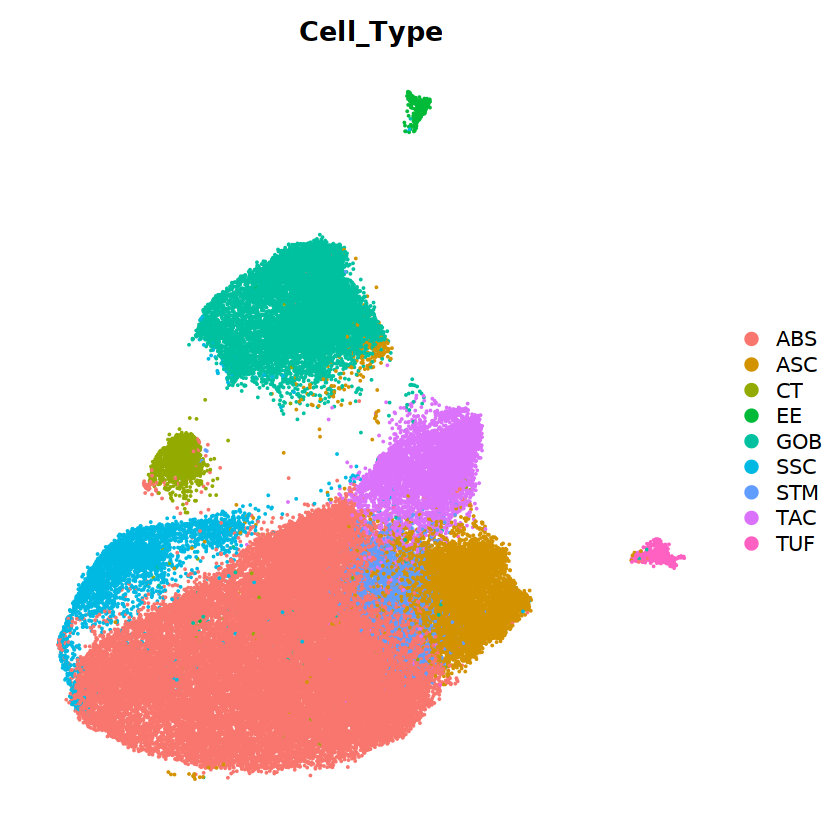

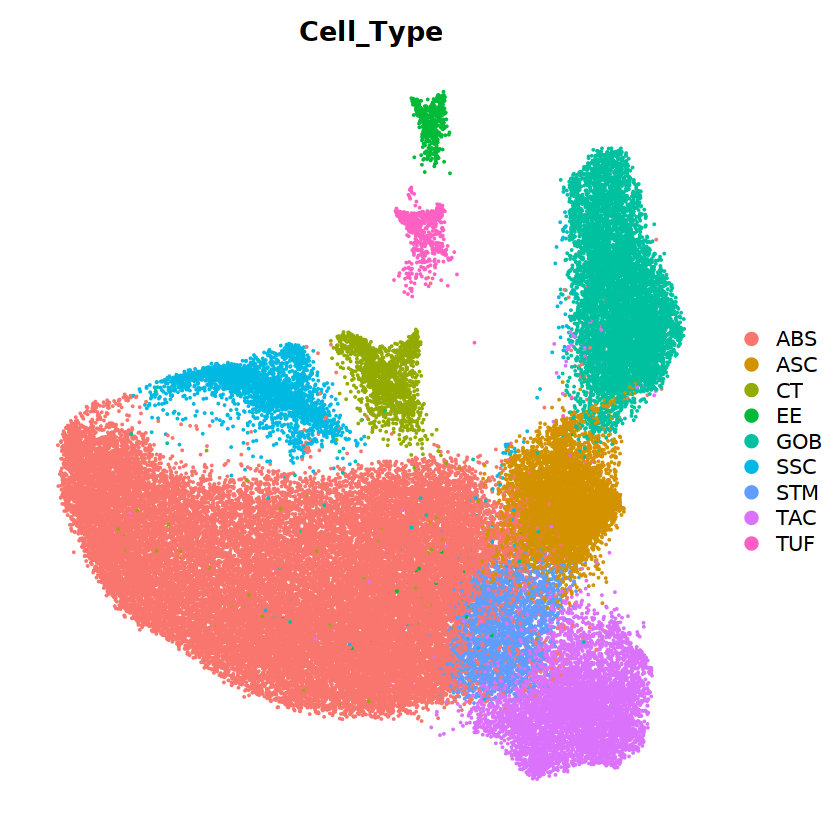

In [3]:
DimPlot(object = epi.dis, reduction = "umap", group.by = "Cell_Type") + NoAxes()
DimPlot(object = epi.val, reduction = "umap", group.by = "Cell_Type") + NoAxes()

In [5]:
epi.dis.filt <- subset(epi.dis, Cell_Type %in% c("ASC", "SSC"))
epi.val.filt <- subset(epi.val, Cell_Type %in% c("ASC", "SSC"))


epi.dis_val.filt <- merge(epi.dis.filt, y = epi.val.filt, add.cell.ids = c("DIS", "VAL"), project = "DIS_VAL")

epi.dis_val.filt
dim(epi.dis_val.filt@meta.data)
head(epi.dis_val.filt@meta.data)

An object of class Seurat 
34614 features across 19312 samples within 1 assay 
Active assay: RNA (34614 features, 0 variable features)

[1] 19312    26

,HTAN Parent Data File ID,HTAN Specimen ID,Cell_Type,Polyp_Type,Sample_Classification,cell_type_ontology_term_id,disease_ontology_term_id,donor_id,assay_ontology_term_id,tissue_ontology_term_id,⋯,cell_type,assay,disease,organism,sex,tissue,self_reported_ethnicity,development_stage,nCount_RNA,nFeature_RNA
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>
DIS_GACTTCTTCGATATGCAT-0,HTA11_3410_200000101113111,HTA11_3410_2000001011,ASC,TA,AD,CL:0001063,MONDO:0024660,HTA11_3410,EFO:0008913,UBERON:0001157,⋯,neoplastic cell,single-cell RNA sequencing,tubular adenoma,Homo sapiens,male,transverse colon,European,70-year-old human stage,13449,3174
DIS_GAACCACGCTACCTTGCC-0,HTA11_3410_200000101113111,HTA11_3410_2000001011,ASC,TA,AD,CL:0001063,MONDO:0024660,HTA11_3410,EFO:0008913,UBERON:0001157,⋯,neoplastic cell,single-cell RNA sequencing,tubular adenoma,Homo sapiens,male,transverse colon,European,70-year-old human stage,3473,1227
DIS_TGCCTCACGTGGAGCT-0,HTA11_3410_200000101113111,HTA11_3410_2000001011,ASC,TA,AD,CL:0001063,MONDO:0024660,HTA11_3410,EFO:0008913,UBERON:0001157,⋯,neoplastic cell,single-cell RNA sequencing,tubular adenoma,Homo sapiens,male,transverse colon,European,70-year-old human stage,10235,2465
DIS_TGAACTAGCCAGGAATAGA-0,HTA11_3410_200000101113111,HTA11_3410_2000001011,ASC,TA,AD,CL:0001063,MONDO:0024660,HTA11_3410,EFO:0008913,UBERON:0001157,⋯,neoplastic cell,single-cell RNA sequencing,tubular adenoma,Homo sapiens,male,transverse colon,European,70-year-old human stage,8249,2701
DIS_AGGGAACGAAGGCAACG-0,HTA11_3410_200000101113111,HTA11_3410_2000001011,ASC,TA,AD,CL:0001063,MONDO:0024660,HTA11_3410,EFO:0008913,UBERON:0001157,⋯,neoplastic cell,single-cell RNA sequencing,tubular adenoma,Homo sapiens,male,transverse colon,European,70-year-old human stage,3894,1353
DIS_AACCTGACAGCAGAAC-0,HTA11_3410_200000101113111,HTA11_3410_2000001011,ASC,TA,AD,CL:0001063,MONDO:0024660,HTA11_3410,EFO:0008913,UBERON:0001157,⋯,neoplastic cell,single-cell RNA sequencing,tubular adenoma,Homo sapiens,male,transverse colon,European,70-year-old human stage,5330,1606


In [6]:
saveRDS(epi.dis_val.filt, "./data/rdsFiles/chen.precancer_crc_states.epi.dis_val.asc_ssc.rds")

# Tsubosaka, A et al., Cell Reports 2023

[Stomach encyclopedia: Combined single-cell and spatial transcriptomics reveal cell diversity and homeostatic regulation of human stomach](https://doi.org/10.1016/j.celrep.2023.113236)

[Data download](https://data.humancellatlas.org/explore/projects/cfece4d2-f18d-44ad-a46a-42bbcb5cb3b7)

In [2]:
obj.tsubosaka <- readRDS("./data/rawFiles/data_9_9_annotated_seurat_all_ut.rds")

obj.tsubosaka
dim(obj.tsubosaka@meta.data)
head(obj.tsubosaka@meta.data)

An object of class Seurat 
33538 features across 91270 samples within 1 assay 
Active assay: RNA (33538 features, 4000 variable features)
 4 dimensional reductions calculated: pca, harmony, tsne, umap

[1] 91270    22

,orig.ident,nCount_RNA,nFeature_RNA,contami_frac,percent.mt,ident,RNA_snn_res.0.5,seurat_clusters,TN,patient,⋯,celltype_singleR,cxds_score,bcds_score,hybrid_score,cells.use,RNA_snn_res.0.8,institution,major_clusters,subcluster,subcluster.v2
,<chr>,<dbl>,<int>,<dbl>,<dbl>,<chr>,<chr>,<fct>,<chr>,<chr>,⋯,<chr>,<dbl>,<dbl>,<dbl>,<lgl>,<fct>,<chr>,<fct>,<chr>,<fct>
10N-total_AAACCTGGTCCAAGTT,10N-total,272.4073,210,0.07911161,2.51934393,11,11,10,N,10,⋯,Hepatocytes,1779.913,0.01872005,0.02044906,TRUE,10,UT,epi,Chief,Chief
10N-total_AAACCTGGTGCACCAC,10N-total,366.5742,264,0.07911161,2.22302374,17,17,12,N,10,⋯,Hepatocytes,9050.223,0.05705699,0.14074042,TRUE,12,UT,epi,Ent,Ent
10N-total_AAACGGGCAACGATCT,10N-total,443.0991,279,0.07911161,17.48033319,1,1,2,N,10,⋯,Epithelial_cells,8141.843,0.48631901,0.57409750,TRUE,2,UT,epi,GKN+F,GKN+F
10N-total_AAAGTAGAGTCACGCC,10N-total,1352.7589,828,0.07911161,0.02691461,15,15,18,N,10,⋯,Epithelial_cells,6030.685,0.12048083,0.17274701,TRUE,18,UT,epi,PC,PC
10N-total_AACCATGGTCCGACGT,10N-total,716.9747,571,0.07911161,22.32086675,1,1,2,N,10,⋯,Epithelial_cells,15298.508,0.20738789,0.36538162,TRUE,2,UT,epi,GKN+F,GKN+F
10N-total_AACCGCGGTCGGCACT,10N-total,2035.2449,964,0.07911161,0.17781584,13,13,12,N,10,⋯,Epithelial_cells,19267.718,0.15910508,0.35955585,TRUE,12,UT,epi,Ent,Ent


In [3]:
Idents(obj.tsubosaka) <- "major_clusters"
levels(Idents(obj.tsubosaka))

[1] "B/plasma" "epi"      "T"        "FB"       "EC"       "Mp"       "mast"

In [4]:
obj.tsubosaka@meta.data <- obj.tsubosaka@meta.data |>
    mutate(ann.goblet = case_when(subcluster == "Gob" ~ "Goblet", .default = "rest"))

table(obj.tsubosaka@meta.data$ann.goblet, useNA = "always")


Goblet   rest   <NA> 
   140  91130      0 

### subset epithelial object

In [5]:
epi.tsubosaka <- subset(x = obj.tsubosaka, subset = major_clusters == "epi")

epi.tsubosaka
dim(epi.tsubosaka@meta.data)
head(epi.tsubosaka@meta.data)

An object of class Seurat 
33538 features across 12109 samples within 1 assay 
Active assay: RNA (33538 features, 4000 variable features)
 4 dimensional reductions calculated: pca, harmony, tsne, umap

[1] 12109    23

,orig.ident,nCount_RNA,nFeature_RNA,contami_frac,percent.mt,ident,RNA_snn_res.0.5,seurat_clusters,TN,patient,⋯,cxds_score,bcds_score,hybrid_score,cells.use,RNA_snn_res.0.8,institution,major_clusters,subcluster,subcluster.v2,ann.goblet
,<chr>,<dbl>,<int>,<dbl>,<dbl>,<chr>,<chr>,<fct>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<lgl>,<fct>,<chr>,<fct>,<chr>,<fct>,<chr>
10N-total_AAACCTGGTCCAAGTT,10N-total,272.4073,210,0.07911161,2.51934393,11,11,10,N,10,⋯,1779.913,0.01872005,0.02044906,TRUE,10,UT,epi,Chief,Chief,rest
10N-total_AAACCTGGTGCACCAC,10N-total,366.5742,264,0.07911161,2.22302374,17,17,12,N,10,⋯,9050.223,0.05705699,0.14074042,TRUE,12,UT,epi,Ent,Ent,rest
10N-total_AAACGGGCAACGATCT,10N-total,443.0991,279,0.07911161,17.48033319,1,1,2,N,10,⋯,8141.843,0.48631901,0.57409750,TRUE,2,UT,epi,GKN+F,GKN+F,rest
10N-total_AAAGTAGAGTCACGCC,10N-total,1352.7589,828,0.07911161,0.02691461,15,15,18,N,10,⋯,6030.685,0.12048083,0.17274701,TRUE,18,UT,epi,PC,PC,rest
10N-total_AACCATGGTCCGACGT,10N-total,716.9747,571,0.07911161,22.32086675,1,1,2,N,10,⋯,15298.508,0.20738789,0.36538162,TRUE,2,UT,epi,GKN+F,GKN+F,rest
10N-total_AACCGCGGTCGGCACT,10N-total,2035.2449,964,0.07911161,0.17781584,13,13,12,N,10,⋯,19267.718,0.15910508,0.35955585,TRUE,12,UT,epi,Ent,Ent,rest


In [6]:
# Remove the existing embeddings inherited from the original object with all compartments
epi.tsubosaka[["pca"]] <- NULL
epi.tsubosaka[["harmony"]] <- NULL
epi.tsubosaka[["tsne"]] <- NULL
epi.tsubosaka[["umap"]] <- NULL

message("NormalizeData...")
epi.tsubosaka <- NormalizeData(object = epi.tsubosaka, 
                               normalization.method = "LogNormalize", 
                               scale.factor = 10000)
message("FindVariableFeatures...")
epi.tsubosaka <- FindVariableFeatures(object = epi.tsubosaka, 
                                      selection.method = "vst", 
                                      nfeatures = 2000)
message("ScaleData...")
epi.tsubosaka <- ScaleData(object = epi.tsubosaka, 
                           features = rownames(epi.tsubosaka))
message("RunPCA...")
epi.tsubosaka <- RunPCA(object = epi.tsubosaka, 
                        features = VariableFeatures(object = epi.tsubosaka))

sigPCs <- 20
groupbyVariable <- "orig.ident"

message("RunHarmony...")
# defaults for for RunHarmony: reduction = "pca", plot_convergence = FALSE,
epi.tsubosaka <- harmony::RunHarmony(object = epi.tsubosaka, 
                                     group.by.vars = groupbyVariable) 

message("RunUMAP...")
epi.tsubosaka <- RunUMAP(object = epi.tsubosaka,
                         seed.use = 1,
                         reduction = "harmony", 
                         dims = 1:sigPCs)

NormalizeData...

FindVariableFeatures...

ScaleData...

Centering and scaling data matrix

RunPCA...

PC_ 1 
Positive:  ARHGDIB, CORO1A, TCL1A, HMGB2, LAPTM5, MS4A1, LIMD2, LCP1, PTPRCAP, RAC2 
	   CD53, NCF1, CD37, CD79B, PTPRC, BCAS4, RGS13, HLA-DQA1, BACH2, LRMP 
	   PTTG1, TUBB, RCSD1, GCSAM, DCK, CD19, CD22, RHOH, HCLS1, VPREB3 
Negative:  S100A6, SPINK1, MT1G, LYZ, PHGR1, KRT8, TFF2, AGR2, KRT19, KRT18 
	   MT1E, IGHA1, MT2A, PIGR, MT1X, PGA5, ADIRF, AKR1B10, EPCAM, LGALS4 
	   LGALS3, CXCL17, C15orf48, FCGBP, IGKC, GPX2, JCHAIN, LCN2, PLAC8, PGA3 
PC_ 2 
Positive:  ANPEP, PRAP1, FABP1, FABP2, RBP2, MTTP, SI, TM4SF20, APOA4, APOB 
	   SLC5A1, CDH17, PCK1, ALDOB, APOC3, APOA1, MALL, MEP1A, DMBT1, CLDN7 
	   SLC6A19, C3orf85, SLC15A1, TMPRSS15, KHK, ACE2, CDHR5, VIL1, CREB3L3, CES2 
Negative:  PGA5, PGA3, IGHA1, CKB, ATP4B, GIF, IGKC, CHIA, JCHAIN, ATP4A 
	   MT1G, CXCL17, IGLC2, MT1X, MT2A, PDIA2, MUC6, NBPF12, IGHA2, MT1E 
	   G0S2, NUPR1, MT1F, IGLC3, MT1M, LEPR, CLIC6, TMED6, 

In [7]:
table(epi.tsubosaka@meta.data$orig.ident)
table(obj.tsubosaka@meta.data$orig.ident)


 10N-Bcell  10N-total  11N-Bcell  11N-total  12N-Bcell  12N-total  14N-Bcell 
       239        390         58        245        201        307        219 
 14N-total  15N-Bcell  15N-total  16N-Bcell  16N-total  17N-Bcell  17N-total 
       353        331        187        257        630        634        879 
 18N-Bcell   3N-Bcell   3N-total   4N-Bcell   4N-total 5N-2-Bcell 5N-2-total 
       161        263        486        153        341        728         30 
  5N-Bcell   5N-total   6N-Bcell   6N-total   7N-Bcell   8N-Bcell   8N-total 
       850        817        227        500        706        831        243 
  9N-Bcell   9N-total 
       271        572 


 10N-Bcell  10N-total  11N-Bcell  11N-total  12N-Bcell  12N-total  14N-Bcell 
      3278       2112        784        903       7336       2746        911 
 14N-total  15N-Bcell  15N-total  16N-Bcell  16N-total  17N-Bcell  17N-total 
       760       3821       1403       3505       2093       8868       5393 
 18N-Bcell   3N-Bcell   3N-total   4N-Bcell   4N-total 5N-2-Bcell 5N-2-total 
      2463       2495       1221       1172       1521       2369         47 
  5N-Bcell   5N-total   6N-Bcell   6N-total   7N-Bcell   8N-Bcell   8N-total 
      2780       2000       6837       2088       6140       8635       2370 
  9N-Bcell   9N-total 
      3391       1828 

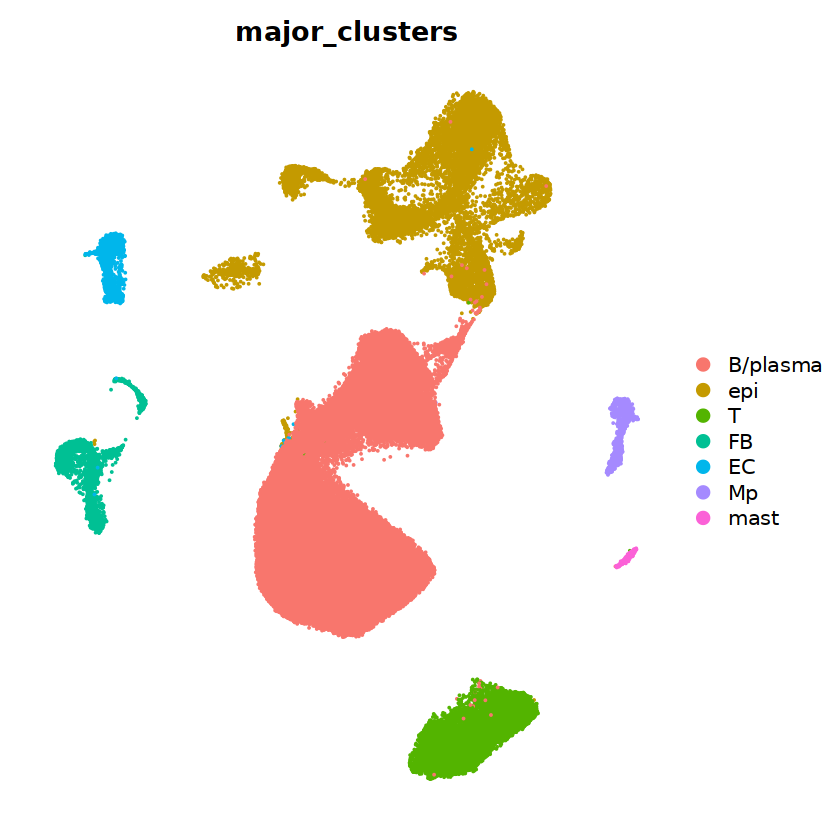

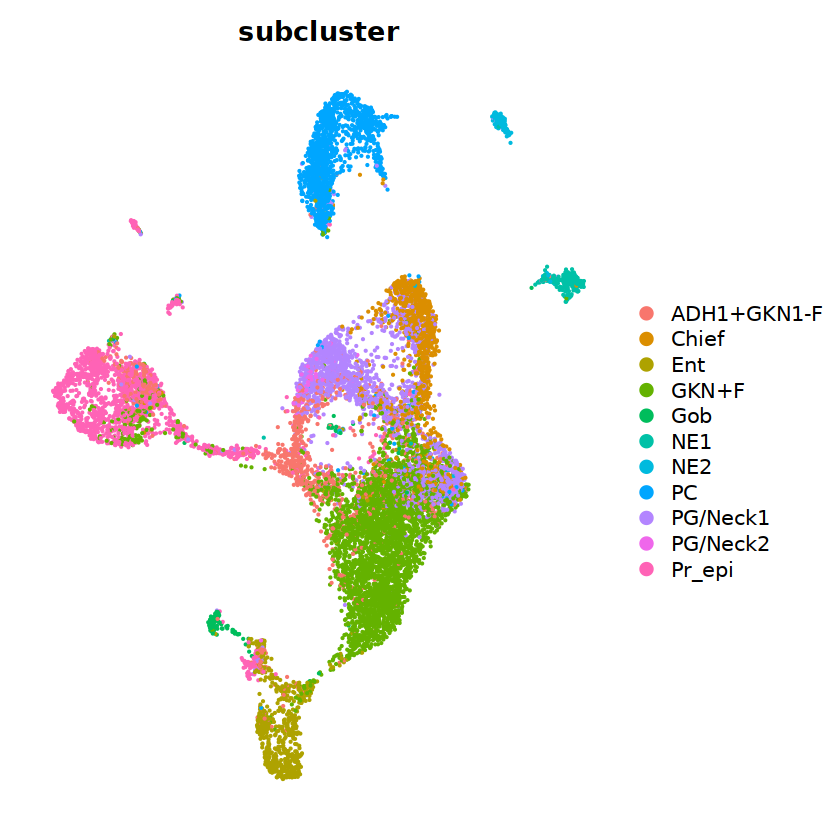

In [8]:
DimPlot(object = obj.tsubosaka, reduction = "umap", group.by = "major_clusters") + NoAxes()
DimPlot(object = epi.tsubosaka, reduction = "umap", group.by = "subcluster") + NoAxes() # epi only; with harmony

In [9]:
saveRDS(epi.tsubosaka, "./data/rdsFiles/tsubosaka.epi.stomach.rds")
saveRDS(obj.tsubosaka, "./data/rdsFiles/tsubosaka.all.stomach.rds")

# Becker, W. R. et al., Nature Genetics 2022

    /scoti
    ..../analysis
    ......../reproduce_RNA_greenleaf.ipynb

go to the `reproduce_RNA_greenleaf.ipynb` for data download instructions. i'm using the seurat object saved in `reproduce_greenleaf_results/initial_full_colon_proj_seurat.rds` as the starting point.
for ease, i've copied the `initial_full_colon_proj_seurat.rds` file in `metaplasia_analysis/data/rawFiles` directory. [Download link for `initial_full_colon_proj_seurat.rds`](https://drive.google.com/file/d/1ojPq6fAmgtYdCv3IbHBkQEkYmKCtXSyw/view?usp=sharing)

[Single-cell analyses define a continuum of cell state and composition changes in the malignant transformation of polyps to colorectal cancer](https://doi.org/10.1038/s41588-022-01088-x)

In [74]:
obj.becker <- readRDS("./data/rawFiles/initial_full_colon_proj_seurat.rds")

obj.becker
dim(obj.becker@meta.data)
head(obj.becker@meta.data)

An object of class Seurat 
26797 features across 208557 samples within 1 assay 
Active assay: RNA (26797 features, 0 variable features)

[1] 208557     33

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,doublet.class,pANN,SampleNameOnly,SimplifiedSampleName,DifferentialGroup,Donor,⋯,Percent_sample_w_any_degree_dysplasia_overall,Pathologist0_PolypType,Pathologist0_HGD,Pathologist0_LGD,Pathologist0_Percent_of_neoplastic_cell_nuclei_as_a_total_of_all_cell_nuclei_in_tumor_ONLY_area,Pathologist0_Percent_nondysplastic_stroma,Pathologist0_Percent_Entire_Tissue_Dysplastic,Sample,CellType,general_cell_type
,<chr>,<dbl>,<int>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
F007_AAACCCATCCGCTGTT-1,F007,577,488,0.0000000,Singlet,0.000000000,F007,F007,F007,F,⋯,30,TA,,y,50,20,40,F007,Stem,epithelial
F007_AAACGCTAGTTTCGGT-1,F007,614,515,0.0000000,Singlet,0.000000000,F007,F007,F007,F,⋯,30,TA,,y,50,20,40,F007,Stem,epithelial
F007_AAACGCTTCAATCAGC-1,F007,912,717,0.1096491,Singlet,0.033557047,F007,F007,F007,F,⋯,30,TA,,y,50,20,40,F007,Stem,epithelial
F007_AAAGAACAGAAGTATC-1,F007,575,465,0.0000000,Singlet,0.006711409,F007,F007,F007,F,⋯,30,TA,,y,50,20,40,F007,Stem,epithelial
F007_AAAGAACCAAAGGAGA-1,F007,572,483,0.0000000,Singlet,0.006711409,F007,F007,F007,F,⋯,30,TA,,y,50,20,40,F007,Immature Goblet,epithelial
F007_AAAGAACCAAGCGGAT-1,F007,561,461,0.0000000,Singlet,0.000000000,F007,F007,F007,F,⋯,30,TA,,y,50,20,40,F007,Immature Goblet,epithelial


In [75]:
table(obj.becker@meta.data$DiseaseState, useNA = "always")
table(obj.becker@meta.data$general_cell_type, useNA = "always")


Adenocarcinoma         Normal          Polyp     Unaffected           <NA> 
         15126          29411         116365          47655              0 


epithelial     immune    stromal       <NA> 
    168086      18609      14111       7751 

In [77]:
obj.becker.epi <- subset(obj.becker, subset = general_cell_type == "epithelial")

obj.becker.epi
table(obj.becker.epi@meta.data$DiseaseState, useNA = "always")

An object of class Seurat 
26797 features across 168086 samples within 1 assay 
Active assay: RNA (26797 features, 0 variable features)


Adenocarcinoma         Normal          Polyp     Unaffected           <NA> 
         12390          16827         105978          32891              0 

In [98]:
obj.becker.epi.polyps <- subset(x = obj.becker.epi, subset = DiseaseState == "Polyp")
obj.becker.epi.polyps

An object of class Seurat 
26797 features across 105978 samples within 1 assay 
Active assay: RNA (26797 features, 0 variable features)

In [99]:
obj.becker.epi.polyps <- NormalizeData(obj.becker.epi.polyps, 
                                       normalization.method = "LogNormalize", 
                                       scale.factor = 10000)
obj.becker.epi.polyps <- FindVariableFeatures(obj.becker.epi.polyps, 
                                              selection.method = "vst", 
                                              nfeatures = 2000)
obj.becker.epi.polyps <- ScaleData(obj.becker.epi.polyps, 
                                   features = VariableFeatures(object = obj.becker.epi.polyps))
obj.becker.epi.polyps <- RunPCA(obj.becker.epi.polyps, 
                                features = VariableFeatures(object = obj.becker.epi.polyps))
sigPCs <- 20
groupbyVariable <- "orig.ident"
obj.becker.epi.polyps <- harmony::RunHarmony(obj.becker.epi.polyps, 
                                             group.by.vars = groupbyVariable) 
obj.becker.epi.polyps <- RunUMAP(obj.becker.epi.polyps,
                                 seed.use = 1,
                                 reduction = "harmony", 
                                 dims = 1:sigPCs)

Centering and scaling data matrix

PC_ 1 
Positive:  PCSK5, TRPM6, MS4A12, PAG1, PDE3A, HHLA2, MICAL2, PIP5K1B, BTNL8, THRB 
	   GDA, GCNT3, LARGE1, EXT1, C1orf21, PTPRR, CEACAM7, LGALS3, MYLK, PLAC8 
	   PDE8A, SLC17A4, KRT20, NR5A2, NEAT1, TCF7L2, TMEM45B, MYO1D, USP53, SLC4A4 
Negative:  L1TD1, SOX4, MTRNR2L12, CENPF, MKI67, SLC12A2, NKD1, TOP2A, CENPE, ASPM 
	   SMOC2, CEMIP, AC078993.1, CLCA1, OLFM4, MYRIP, DLGAP5, KIF20B, XACT, TPX2 
	   KIF15, NUSAP1, GTSE1, NUPR1, APOLD1, IQGAP3, RETNLB, APCDD1, ADAMTSL2, LINC01632 
PC_ 2 
Positive:  DACH1, IMMP2L, SLC12A2, OLFM4, GMDS, CACNB2, SAMD5, CHRM3, ZBTB20, GPHN 
	   FHIT, CDK6, ZNRF3, GRIN2B, KANK1, STXBP6, PTPRK, AL033504.1, MECOM, DLEU2 
	   POU6F2, ARID5B, C9orf3, RAD51B, TMTC2, PTPRG, NAALADL2, MAML3, LINC01572, GRIP1 
Negative:  SLC26A3, MS4A12, SLC9A3, CDHR5, TRPM6, SCNN1B, CLCA4, SLC26A2, TMIGD1, PTPRR 
	   GCNT3, AHNAK, SLC20A1, MYLK, HHLA2, CEACAM7, CA4, HSD17B2, CEACAM1, DHRS9 
	   KRT20, SGK1, SLC51A, SLC17A4, PRSS12, PLAC8

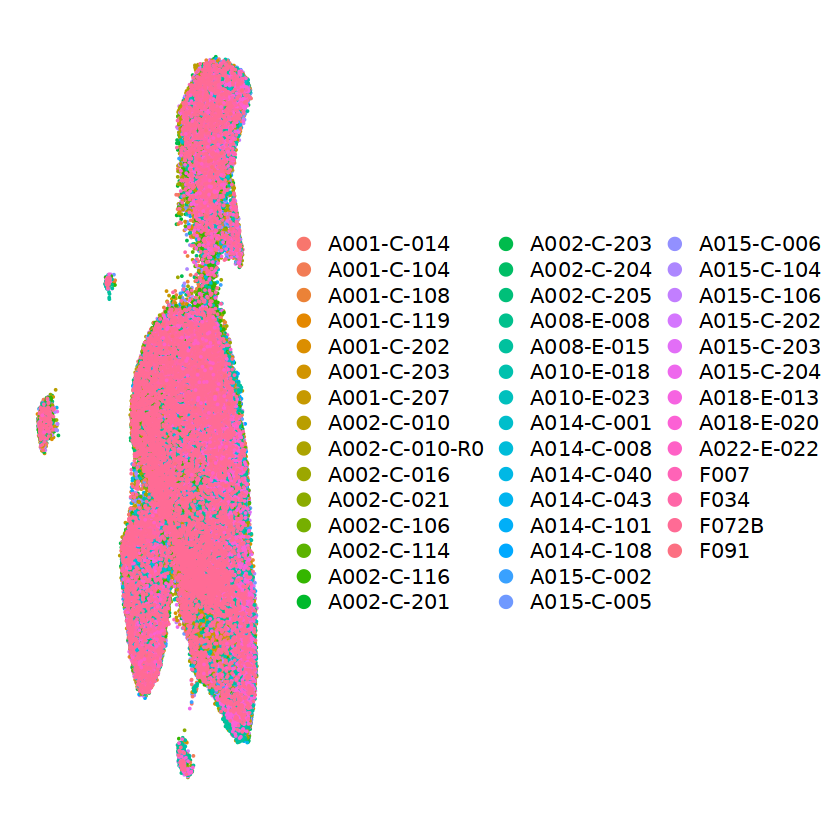

In [100]:
DimPlot(obj.becker.epi.polyps, raster = F) + NoAxes()

In [101]:
saveRDS(obj.becker.epi.polyps, "./data/rdsFiles/becker.polyps.epithelial_colon.with_harmony.rds")